In [12]:
# ==========================================================
# CUSTOMER BEHAVIOR ANALYSIS
# ALFIDO TECH INTERNSHIP PROJECT
# PART 1 : IMPORT, LOAD, CLEANING & FEATURE ENGINEERING
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"]=(10,6)

print("="*80)
print("ALFIDO TECH INTERNSHIP PROJECT")
print("="*80)

# ==========================
# LOAD BOTH DATASETS
# ==========================

df1 = pd.read_csv("/content/ecommerce_customer_data_large.csv")
df2 = pd.read_csv("/content/ecommerce_customer_data_custom_ratios.csv")

print("\nDataset 1 Shape :",df1.shape)
print("Dataset 2 Shape :",df2.shape)

# ==========================
# CONCAT DATASETS
# ==========================

df = pd.concat([df1,df2],ignore_index=True)

print("\nCombined Dataset Shape :",df.shape)

# ==========================
# FIRST 5 ROWS
# ==========================

display(df.head())

# ==========================
# LAST 5 ROWS
# ==========================

display(df.tail())

# ==========================
# DATASET INFORMATION
# ==========================

print("="*80)
print("DATASET INFORMATION")
print("="*80)

df.info()

# ==========================
# CHECK DATA TYPES
# ==========================

print("\nData Types\n")

display(df.dtypes)

# ==========================
# CONVERT PURCHASE DATE
# ==========================

df["Purchase Date"]=pd.to_datetime(df["Purchase Date"])

# ==========================
# CHECK DUPLICATES
# ==========================

duplicate_rows=df.duplicated().sum()

print("\nDuplicate Rows :",duplicate_rows)

df=df.drop_duplicates()

print("After Removing Duplicates :",df.shape)

# ==========================
# CHECK MISSING VALUES
# ==========================

missing=pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":round((df.isnull().sum()/len(df))*100,2)

})

print("\nMissing Value Report\n")

display(missing)

# ==========================
# SUMMARY STATISTICS
# ==========================

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

display(df.describe(include="all"))

# ==========================
# MEAN
# ==========================

print("\nMean\n")

display(df.mean(numeric_only=True))

# ==========================
# MEDIAN
# ==========================

print("\nMedian\n")

display(df.median(numeric_only=True))

# ==========================
# MODE
# ==========================

print("\nMode\n")

display(df.mode().iloc[0])

# ==========================
# UNIQUE VALUES
# ==========================

print("="*80)
print("UNIQUE VALUES")
print("="*80)

for col in df.columns:

    print(col)

    print(df[col].nunique())

    print("-"*40)

# ==========================
# FEATURE ENGINEERING
# ==========================

df["Year"]=df["Purchase Date"].dt.year

df["Month"]=df["Purchase Date"].dt.month_name()

df["Month Number"]=df["Purchase Date"].dt.month

df["Day"]=df["Purchase Date"].dt.day_name()

df["Quarter"]=df["Purchase Date"].dt.quarter

# ==========================
# AGE GROUP
# ==========================

df["Age Group"]=pd.cut(

    df["Age"],

    bins=[18,25,35,45,55,65,100],

    labels=[

        "18-25",

        "26-35",

        "36-45",

        "46-55",

        "56-65",

        "65+"

    ]

)

# ==========================
# PURCHASE CATEGORY
# ==========================

df["Purchase Level"]=pd.qcut(

    df["Total Purchase Amount"],

    q=3,

    labels=[

        "Low",

        "Medium",

        "High"

    ]

)

# ==========================
# FINAL DATASET
# ==========================

print("="*80)
print("FINAL DATASET")
print("="*80)

display(df.head())

print(df.shape)

# ==========================
# SAVE CLEAN DATASET
# ==========================

df.to_csv(

    "Cleaned_Customer_Behavior_Dataset.csv",

    index=False

)

print("\nDataset Saved Successfully!")

print("="*80)
print("PART 1 COMPLETED")
print("="*80)

ALFIDO TECH INTERNSHIP PROJECT

Dataset 1 Shape : (250000, 13)
Dataset 2 Shape : (250000, 13)

Combined Dataset Shape : (500000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
499995,33308,2023-08-10 13:39:06,Clothing,279,2,2187,PayPal,55,1.0,Michelle Flores,55,Male,1
499996,48835,2021-11-23 01:30:42,Home,27,1,3615,Credit Card,42,1.0,Jeremy Rush,42,Female,1
499997,21019,2020-07-02 14:04:48,Home,17,5,2466,Cash,41,0.0,Tina Craig,41,Male,0
499998,49234,2020-12-30 02:02:40,Books,398,2,3668,Crypto,34,0.0,Jennifer Cooper,34,Female,1
499999,16971,2021-03-13 16:28:35,Electronics,425,4,2370,Cash,36,1.0,Justin Lawson,36,Female,1


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            500000 non-null  int64  
 1   Purchase Date          500000 non-null  object 
 2   Product Category       500000 non-null  object 
 3   Product Price          500000 non-null  int64  
 4   Quantity               500000 non-null  int64  
 5   Total Purchase Amount  500000 non-null  int64  
 6   Payment Method         500000 non-null  object 
 7   Customer Age           500000 non-null  int64  
 8   Returns                405022 non-null  float64
 9   Customer Name          500000 non-null  object 
 10  Age                    500000 non-null  int64  
 11  Gender                 500000 non-null  object 
 12  Churn                  500000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 49.6+ MB

Data Types

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


...


Mode



,0
Customer ID,8770
Purchase Date,2020-12-12 05:31:21
Product Category,Clothing
Product Price,119.0
Quantity,4.0
Total Purchase Amount,4674.0
Payment Method,Credit Card
Customer Age,22.0
Returns,0.0
Customer Name,Michael Smith


UNIQUE VALUES
Customer ID
49998
----------------------------------------
Purchase Date
498925
----------------------------------------
Product Category
4
----------------------------------------
Product Price
491
----------------------------------------
Quantity
5
----------------------------------------
Total Purchase Amount
5251
----------------------------------------
Payment Method
4
----------------------------------------
Customer Age
53
----------------------------------------
Returns
2
----------------------------------------
Customer Name
70492
----------------------------------------
Age
53
----------------------------------------
Gender
2
----------------------------------------
Churn
2
----------------------------------------
FINAL DATASET


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Year,Month,Month Number,Day,Quarter,Age Group,Purchase Level
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,2023,May,5,Wednesday,2,26-35,Medium
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,2021,May,5,Sunday,2,26-35,Medium
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,2020,July,7,Monday,3,26-35,Medium
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,2023,January,1,Tuesday,1,26-35,Low
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,2021,May,5,Saturday,2,26-35,Medium


(500000, 20)

Dataset Saved Successfully!
PART 1 COMPLETED


PART 2 : EXPLORATORY DATA ANALYSIS


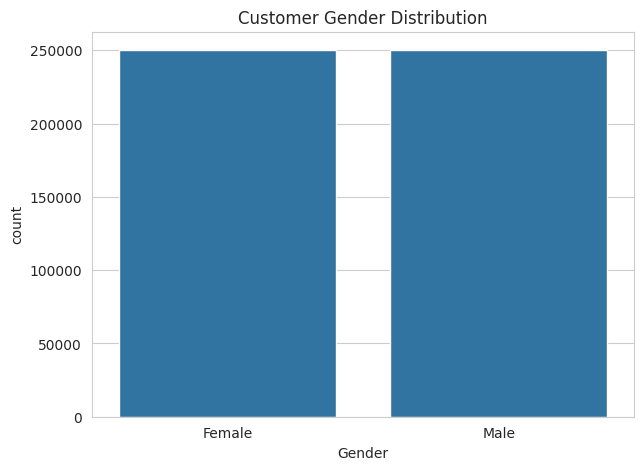

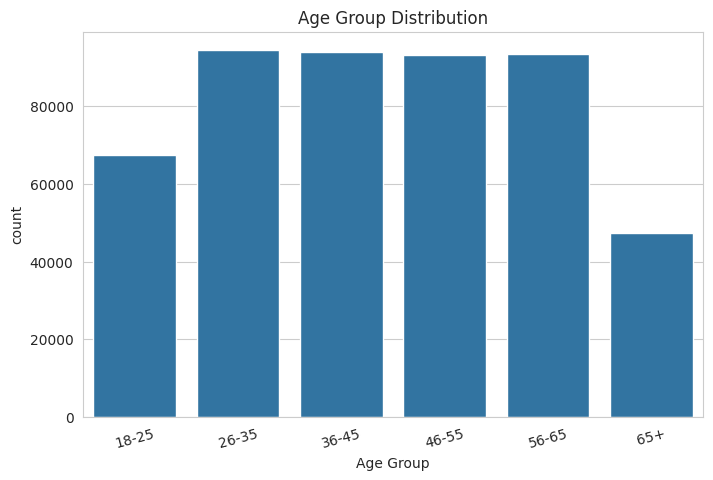

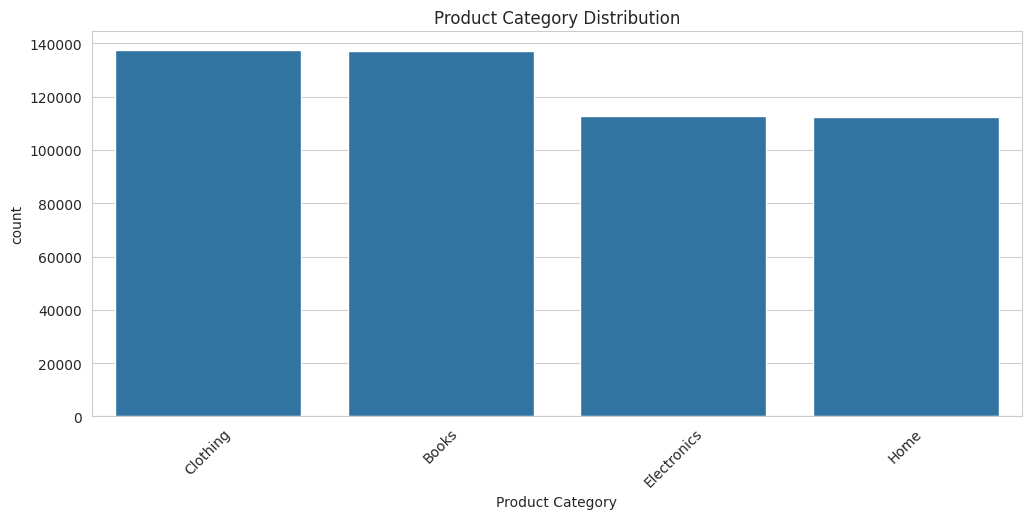

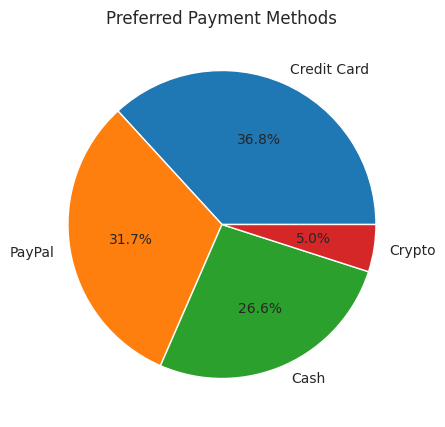

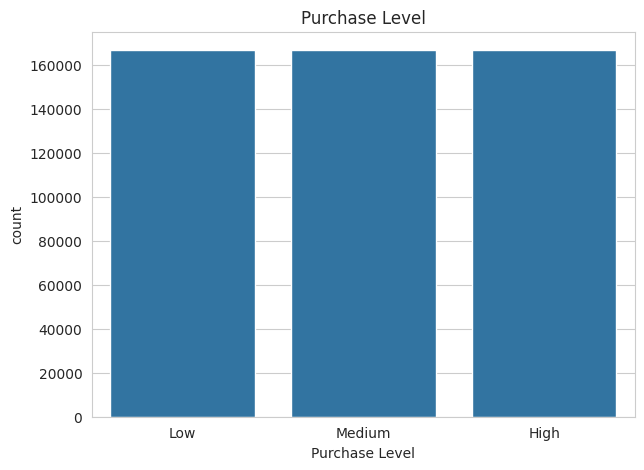

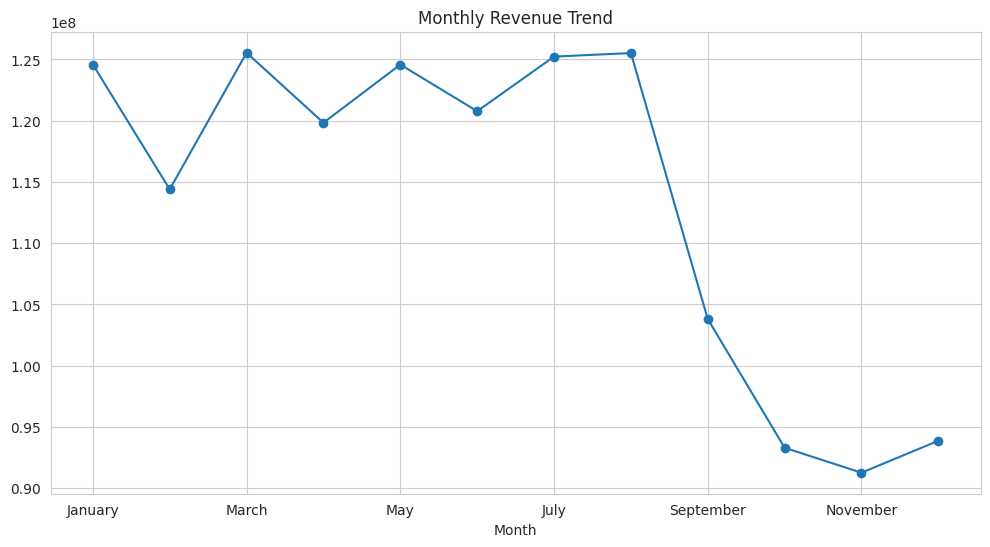

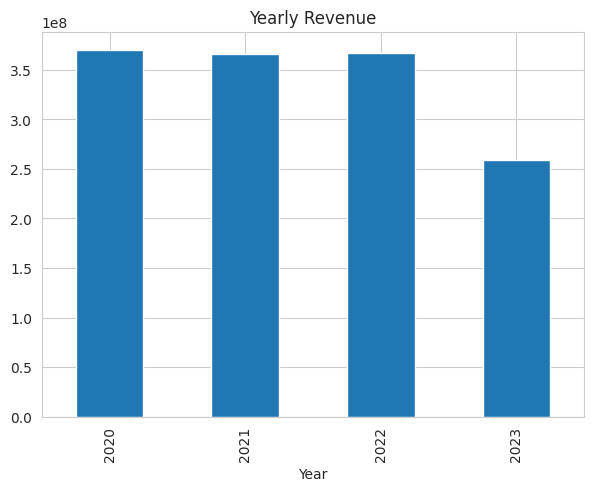

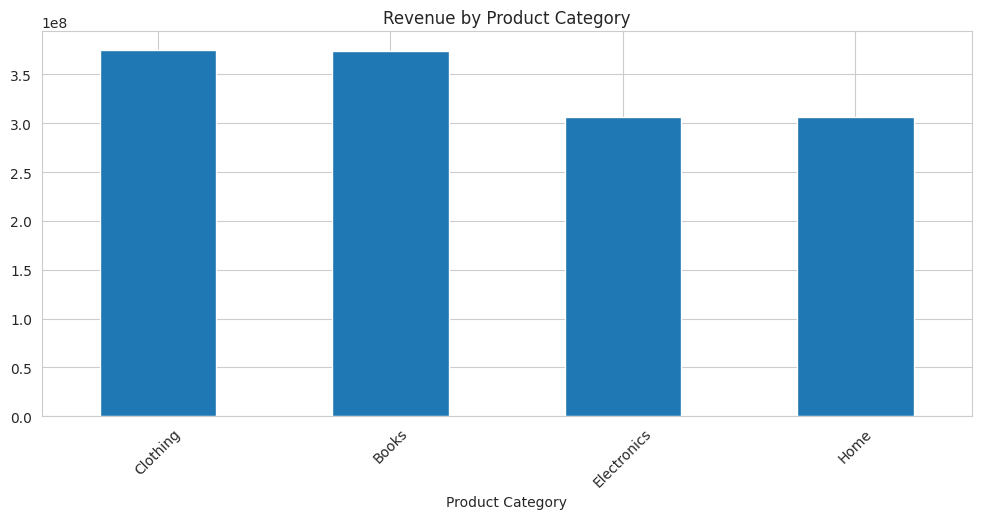

,Total Purchase Amount
Product Category,
Clothing,375248527
Books,374284837
Electronics,306745492
Home,306410126


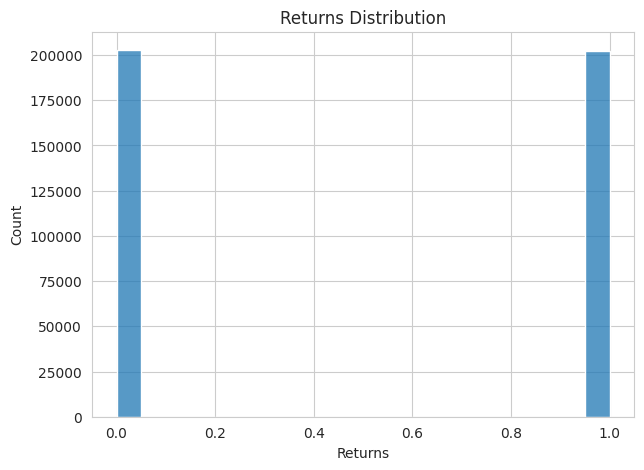

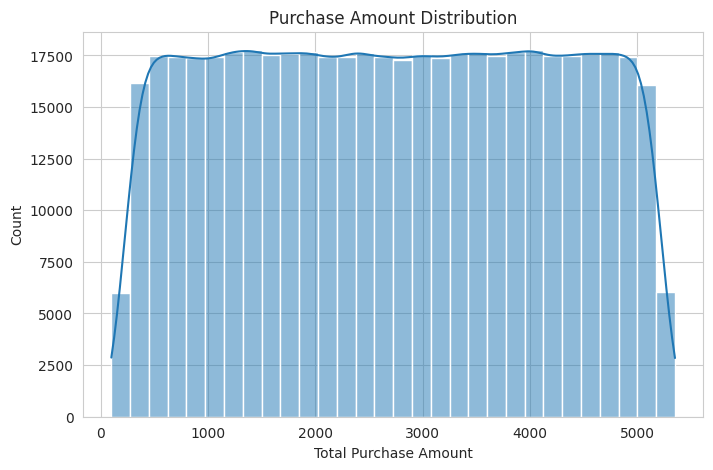

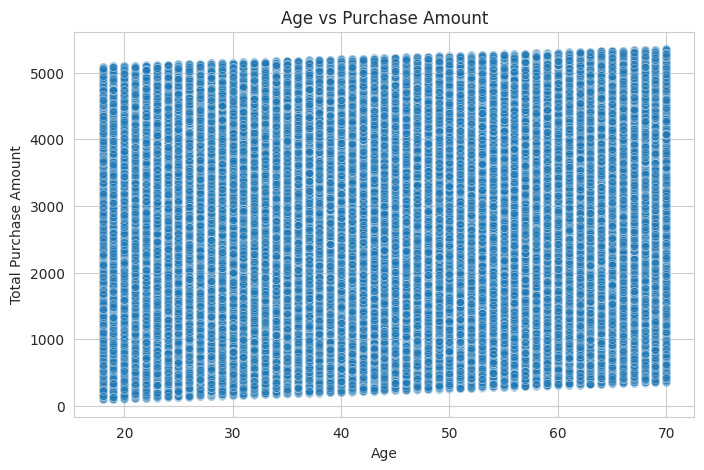

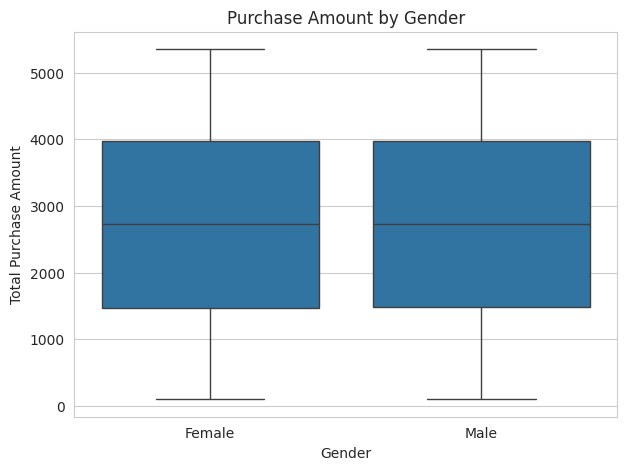

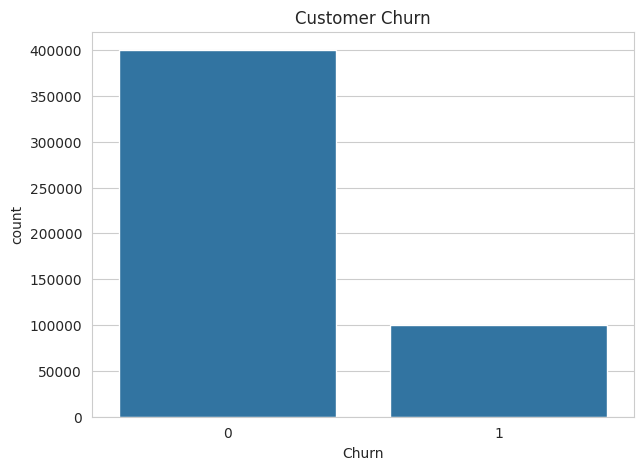

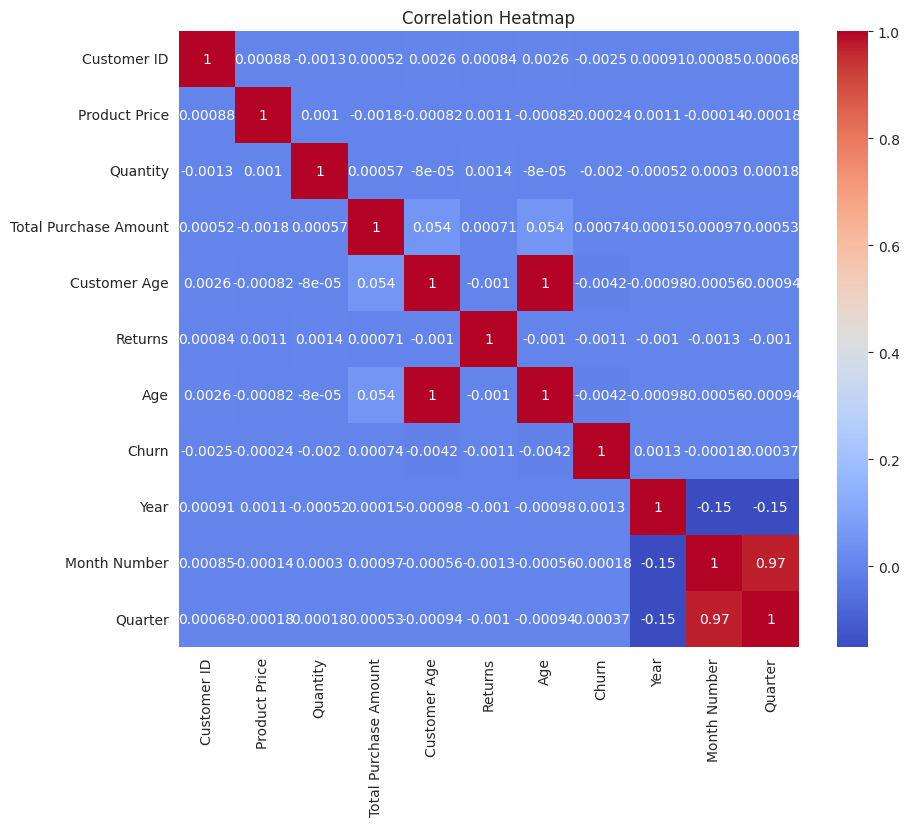

,Total Purchase Amount
Customer ID,
42196,76910
36437,74138
49743,72526
24940,71661
19409,71463
31712,71208
15489,70937
1195,70624
45116,69857


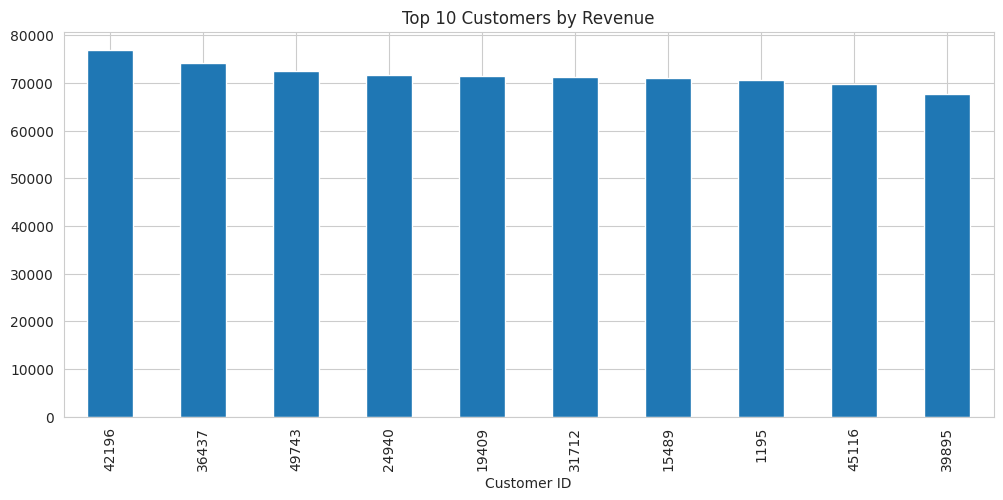

SUMMARY TABLES

Top Product Categories


,Total Purchase Amount
Product Category,
Clothing,375248527
Books,374284837
Electronics,306745492
Home,306410126



Monthly Sales


,Total Purchase Amount
Month,
January,124579927
February,114393384
March,125546573
April,119829356
May,124578860
June,120773822
July,125229375
August,125518312
September,103809638



Top Customers


,Total Purchase Amount
Customer ID,
42196,76910
36437,74138
49743,72526
24940,71661
19409,71463
31712,71208
15489,70937
1195,70624
45116,69857


PART 2 COMPLETED SUCCESSFULLY


In [13]:
# ==========================================================
# PART 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

print("="*80)
print("PART 2 : EXPLORATORY DATA ANALYSIS")
print("="*80)

# ==========================================================
# SET STYLE
# ==========================================================

sns.set_style("whitegrid")

# ==========================================================
# 1. GENDER DISTRIBUTION
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")

plt.show()

# ==========================================================
# 2. AGE GROUP DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Age Group")

plt.title("Age Group Distribution")

plt.xticks(rotation=15)

plt.show()

# ==========================================================
# 3. PRODUCT CATEGORY
# ==========================================================

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Product Category",
    order=df["Product Category"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Product Category Distribution")

plt.show()

# ==========================================================
# 4. PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(8,5))

df["Payment Method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Preferred Payment Methods")

plt.show()

# ==========================================================
# 5. PURCHASE LEVEL
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Purchase Level",
    order=["Low","Medium","High"]
)

plt.title("Purchase Level")

plt.show()

# ==========================================================
# 6. MONTHLY SALES
# ==========================================================

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.grid(True)

plt.show()

# ==========================================================
# 7. YEARLY SALES
# ==========================================================

plt.figure(figsize=(7,5))

df.groupby("Year")["Total Purchase Amount"].sum().plot(kind="bar")

plt.title("Yearly Revenue")

plt.show()

# ==========================================================
# 8. TOP PRODUCT CATEGORY BY SALES
# ==========================================================

sales = df.groupby("Product Category")["Total Purchase Amount"].sum()

sales = sales.sort_values(ascending=False)

plt.figure(figsize=(12,5))

sales.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.xticks(rotation=45)

plt.show()

display(sales)

# ==========================================================
# 9. RETURNS
# ==========================================================

plt.figure(figsize=(7,5))

sns.histplot(df["Returns"], bins=20)

plt.title("Returns Distribution")

plt.show()

# ==========================================================
# 10. TOTAL PURCHASE AMOUNT
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Purchase Amount"],
    bins=30,
    kde=True
)

plt.title("Purchase Amount Distribution")

plt.show()

# ==========================================================
# 11. AGE VS PURCHASE
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(

    data=df,

    x="Age",

    y="Total Purchase Amount",

    alpha=0.4

)

plt.title("Age vs Purchase Amount")

plt.show()

# ==========================================================
# 12. PURCHASE BY GENDER
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(

    data=df,

    x="Gender",

    y="Total Purchase Amount"

)

plt.title("Purchase Amount by Gender")

plt.show()

# ==========================================================
# 13. CHURN DISTRIBUTION
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="Churn"

)

plt.title("Customer Churn")

plt.show()

# ==========================================================
# 14. CORRELATION HEATMAP
# ==========================================================

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(

    numeric.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# 15. TOP 10 CUSTOMERS
# ==========================================================

top_customer = (

    df.groupby("Customer ID")["Total Purchase Amount"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

display(top_customer)

plt.figure(figsize=(12,5))

top_customer.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")

plt.show()

# ==========================================================
# BASIC SUMMARY TABLES
# ==========================================================

print("="*80)
print("SUMMARY TABLES")
print("="*80)

print("\nTop Product Categories")

display(sales.head())

print("\nMonthly Sales")

display(monthly_sales)

print("\nTop Customers")

display(top_customer)

print("="*80)
print("PART 2 COMPLETED SUCCESSFULLY")
print("="*80)

PART 3A : CUSTOMER SEGMENTATION

Customer Level Dataset Shape : (49998, 9)


,Customer ID,Purchase Date,Total Purchase Amount,Quantity,Age,Gender,Returns,Churn,Frequency
0,1,2023-07-19 19:09:20,9781,20,67,Female,1.0,0,4
1,2,2023-07-03 17:26:19,24469,26,42,Female,5.0,0,9
2,3,2023-06-18 12:31:42,32010,38,31,Male,3.0,0,12
3,4,2023-05-12 10:50:24,16541,28,37,Male,4.0,1,9
4,5,2023-03-28 13:30:55,22293,46,24,Female,7.0,0,13


RFM TABLE


,Customer ID,Recency,Frequency,Monetary
0,1,58,4,9781
1,2,74,9,24469
2,3,89,12,32010
3,4,127,9,16541
4,5,171,13,22293



RFM Summary Statistics


...


RFM Scoring Completed


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score
0,1,58,4,9781,3,1,1,311
1,2,74,9,24469,3,2,2,322
2,3,89,12,32010,3,3,3,333
3,4,127,9,16541,2,2,1,221
4,5,171,13,22293,2,4,2,242



Clustering Features


,Recency,Frequency,Monetary,Quantity,Age
0,58,4,9781,20,67
1,74,9,24469,26,42
2,89,12,32010,38,31
3,127,9,16541,28,37
4,171,13,22293,46,24



Data Standardization Completed


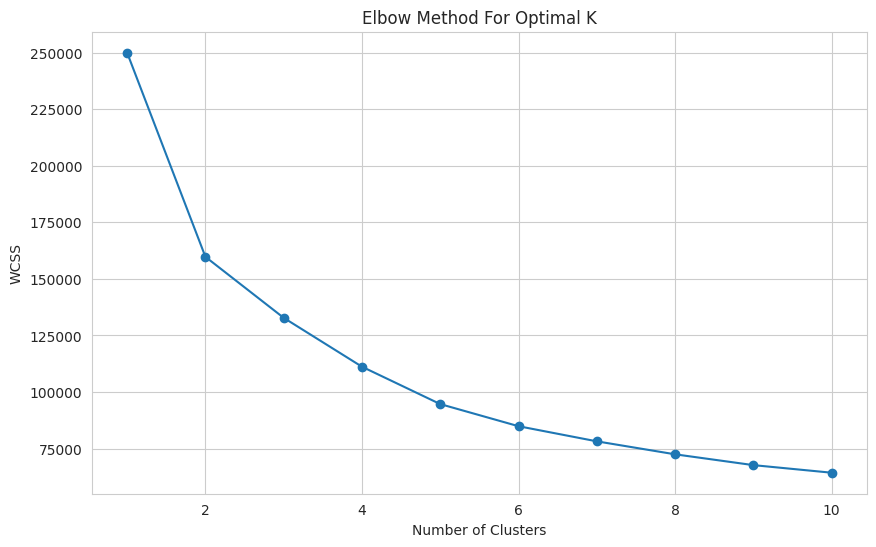


Observe the Elbow Curve.

Choose the point where WCSS starts decreasing slowly.

For this project we will use:
Number of Clusters = 4


Cluster Assignment Completed Successfully!

Cluster Distribution


,count
Cluster,
0,7837
1,13043
2,14318
3,14800


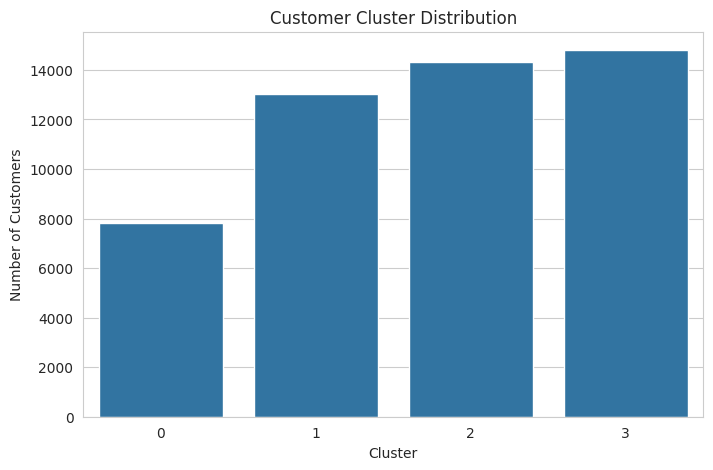


Customer Level Dataset Saved Successfully!
PART 3A COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# ALFIDO TECH INTERNSHIP PROJECT
# PART 3A : CUSTOMER SEGMENTATION (RFM + K-MEANS)
# ==========================================================

print("="*80)
print("PART 3A : CUSTOMER SEGMENTATION")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================================
# CUSTOMER LEVEL DATASET
# ==========================================================

customer_df = (
    df.groupby("Customer ID")
      .agg({
          "Purchase Date": "max",
          "Total Purchase Amount": "sum",
          "Quantity": "sum",
          "Age": "first",
          "Gender": "first",
          "Returns": "sum",
          "Churn": "max"
      })
      .reset_index()
)

# Frequency = Number of Transactions
frequency = (
    df.groupby("Customer ID")
      .size()
      .reset_index(name="Frequency")
)

customer_df = customer_df.merge(
    frequency,
    on="Customer ID",
    how="left"
)

print("\nCustomer Level Dataset Shape :", customer_df.shape)

display(customer_df.head())

# ==========================================================
# CREATE RFM FEATURES
# ==========================================================

reference_date = df["Purchase Date"].max() + pd.Timedelta(days=1)

customer_df["Recency"] = (
    reference_date - customer_df["Purchase Date"]
).dt.days

customer_df.rename(
    columns={
        "Total Purchase Amount": "Monetary"
    },
    inplace=True
)

rfm = customer_df[
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

print("="*80)
print("RFM TABLE")
print("="*80)

display(rfm.head())

print("\nRFM Summary Statistics")

display(rfm.describe())

# ==========================================================
# RFM SCORING
# ==========================================================

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4,3,2,1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=[1,2,3,4],
    duplicates="drop"
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=[1,2,3,4],
    duplicates="drop"
)

rfm["RFM Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

print("\nRFM Scoring Completed")

display(rfm.head())

# ==========================================================
# MERGE RFM BACK
# ==========================================================

customer_df = customer_df.merge(
    rfm[
        [
            "Customer ID",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM Score"
        ]
    ],
    on="Customer ID",
    how="left"
)

# ==========================================================
# PREPARE DATA FOR CLUSTERING
# ==========================================================

cluster_features = customer_df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Quantity",
        "Age"
    ]
]

print("\nClustering Features")

display(cluster_features.head())

# ==========================================================
# STANDARDIZE FEATURES
# ==========================================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

print("\nData Standardization Completed")

# ==========================================================
# ELBOW METHOD
# ==========================================================

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method For Optimal K")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

print("""
Observe the Elbow Curve.

Choose the point where WCSS starts decreasing slowly.

For this project we will use:
Number of Clusters = 4
""")

# ==========================================================
# FINAL KMEANS MODEL
# ==========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

print("\nCluster Assignment Completed Successfully!")

# ==========================================================
# CLUSTER DISTRIBUTION
# ==========================================================

cluster_count = (
    customer_df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster Distribution")

display(cluster_count)

plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_df,
    x="Cluster"
)

plt.title("Customer Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

# ==========================================================
# SAVE CUSTOMER DATASET
# ==========================================================

customer_df.to_csv(
    "Customer_Level_Dataset.csv",
    index=False
)

print("\nCustomer Level Dataset Saved Successfully!")

print("="*80)
print("PART 3A COMPLETED SUCCESSFULLY")
print("="*80)

PART 3B : CLUSTER PROFILING & BUSINESS REPORTING

Cluster Profile


,Recency,Frequency,Monetary,Quantity,Age,Returns,Churn
Cluster,,,,,,,
0,334.15,6.20,16407.72,18.13,44.47,2.48,0.35
1,91.75,13.91,38897.66,42.67,43.69,5.63,0.36
2,106.05,9.37,25646.87,27.86,58.05,3.80,0.36
3,101.84,9.18,24293.75,27.26,29.87,3.72,0.36



Cluster Size


,count
Cluster,
0,7837
1,13043
2,14318
3,14800



Customer Segment Distribution


,count
Customer Segment,
Regular,14800
Loyal,14318
High Value,13043
At Risk,7837


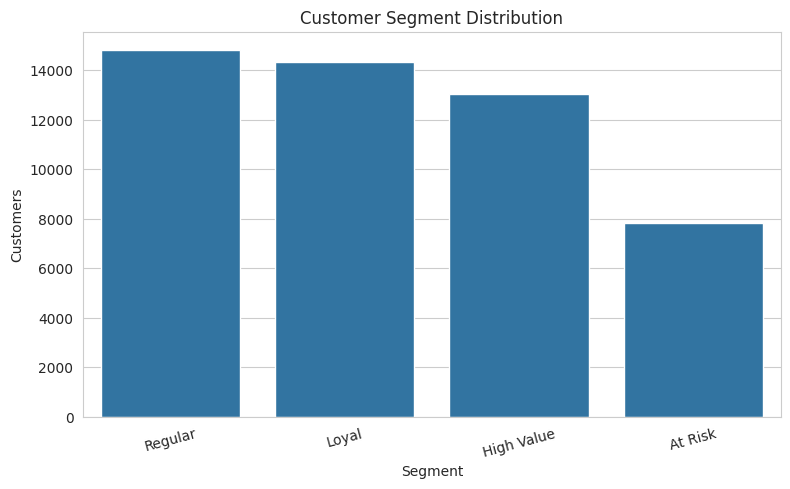

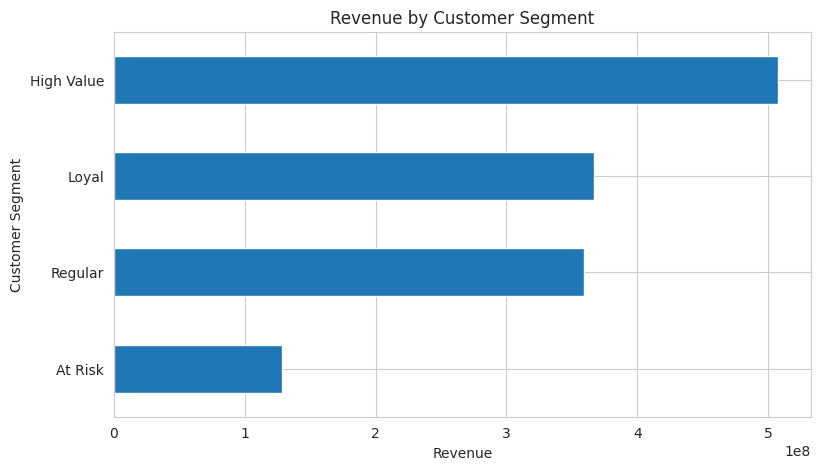

,Monetary
Customer Segment,
At Risk,128587327
High Value,507342210
Loyal,367211918
Regular,359547527


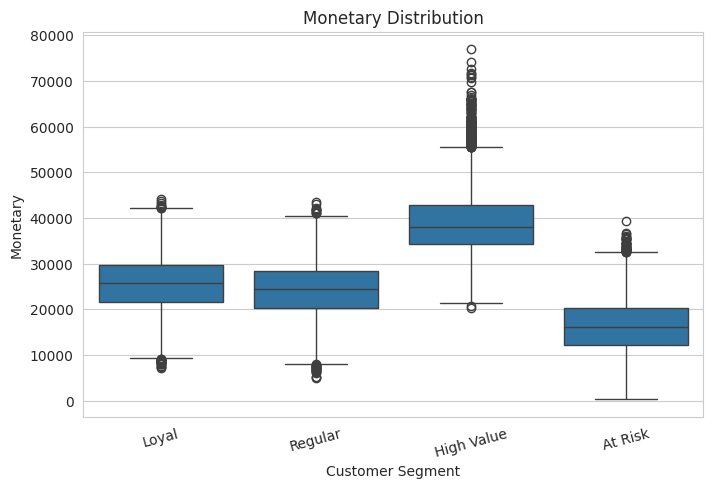

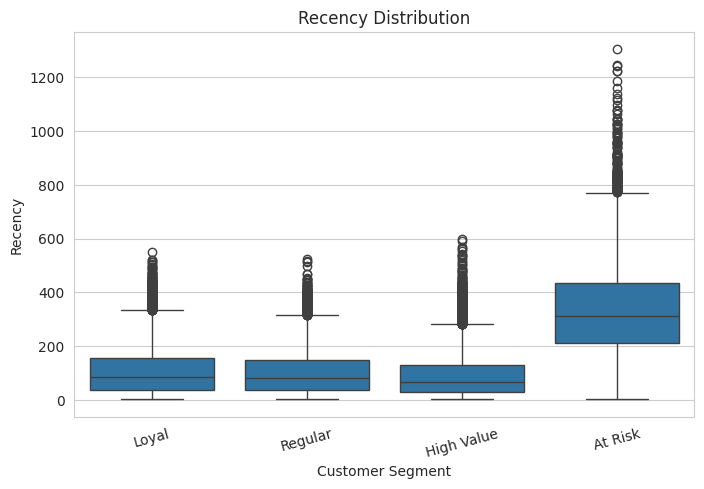

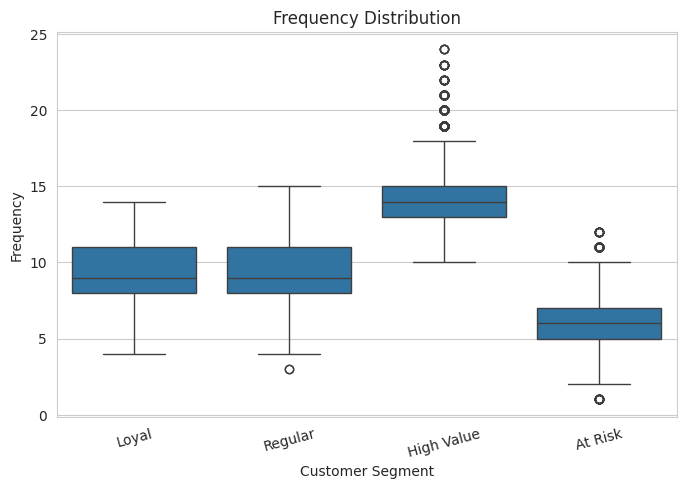

TOP 10 HIGH VALUE CUSTOMERS


,Customer ID,Purchase Date,Monetary,Quantity,Age,Gender,Returns,Churn,Frequency,Recency,R_Score,F_Score,M_Score,RFM Score,Cluster,Customer Segment
42193,42196,2023-07-23 20:52:02,76910,73,59,Male,11.0,0,23,54,3,4,4,344,1,High Value
36434,36437,2023-08-25 12:36:58,74138,68,70,Male,9.0,0,24,21,4,4,4,444,1,High Value
49740,49743,2023-07-28 03:20:38,72526,66,21,Male,10.0,0,22,50,3,4,4,344,1,High Value
24938,24940,2023-09-07 17:48:24,71661,59,69,Female,9.0,1,21,8,4,4,4,444,1,High Value
19407,19409,2023-09-06 08:45:24,71463,72,60,Female,13.0,1,24,10,4,4,4,444,1,High Value
31710,31712,2023-07-13 11:59:31,71208,73,39,Female,10.0,0,23,65,3,4,4,344,1,High Value
15487,15489,2023-05-26 19:11:32,70937,54,69,Female,13.0,0,21,112,2,4,4,244,1,High Value
1194,1195,2023-09-01 21:32:49,70624,56,62,Male,11.0,0,20,14,4,4,4,444,1,High Value
45113,45116,2023-08-04 09:52:04,69857,68,53,Female,8.0,1,21,43,3,4,4,344,1,High Value
39892,39895,2023-06-12 15:45:56,67601,55,63,Male,7.0,0,20,95,3,4,4,344,1,High Value


TOP 10 FREQUENT CUSTOMERS


,Customer ID,Purchase Date,Monetary,Quantity,Age,Gender,Returns,Churn,Frequency,Recency,R_Score,F_Score,M_Score,RFM Score,Cluster,Customer Segment
36434,36437,2023-08-25 12:36:58,74138,68,70,Male,9.0,0,24,21,4,4,4,444,1,High Value
8769,8770,2023-08-30 13:08:09,60235,74,45,Female,5.0,0,24,16,4,4,4,444,1,High Value
19407,19409,2023-09-06 08:45:24,71463,72,60,Female,13.0,1,24,10,4,4,4,444,1,High Value
46626,46629,2023-09-14 10:25:08,64477,62,28,Female,9.0,0,24,2,4,4,4,444,1,High Value
6019,6020,2023-06-05 14:29:51,62184,66,31,Female,6.0,1,23,102,2,4,4,244,1,High Value
31710,31712,2023-07-13 11:59:31,71208,73,39,Female,10.0,0,23,65,3,4,4,344,1,High Value
42294,42297,2023-06-21 00:25:16,65529,62,23,Female,11.0,0,23,87,3,4,4,344,1,High Value
42193,42196,2023-07-23 20:52:02,76910,73,59,Male,11.0,0,23,54,3,4,4,344,1,High Value
36946,36949,2023-09-02 20:39:45,67541,72,37,Female,10.0,1,23,13,4,4,4,444,1,High Value
26758,26760,2023-08-04 04:56:20,49850,83,22,Female,14.0,0,23,43,3,4,4,344,1,High Value


TOP 10 AT RISK CUSTOMERS


,Customer ID,Purchase Date,Monetary,Quantity,Age,Gender,Returns,Churn,Frequency,Recency,R_Score,F_Score,M_Score,RFM Score,Cluster,Customer Segment
33237,33239,2020-02-20 01:56:27,3029,5,56,Female,0.0,1,1,1304,1,1,1,111,0,At Risk
28794,28796,2020-04-16 23:05:53,292,5,44,Male,0.0,0,1,1247,1,1,1,111,0,At Risk
35152,35155,2020-04-20 18:59:35,4712,4,60,Male,1.0,0,1,1243,1,1,1,111,0,At Risk
17256,17258,2020-05-09 19:44:59,260,4,36,Female,1.0,0,1,1224,1,1,1,111,0,At Risk
21310,21312,2020-05-12 09:46:01,3579,11,29,Male,2.0,1,3,1222,1,1,1,111,0,At Risk
29018,29020,2020-06-16 08:06:47,602,4,67,Female,0.0,0,1,1187,1,1,1,111,0,At Risk
4090,4091,2020-07-13 17:32:56,1163,1,22,Male,0.0,1,1,1159,1,1,1,111,0,At Risk
9190,9191,2020-08-03 06:02:04,2995,1,37,Male,0.0,0,1,1139,1,1,1,111,0,At Risk
45704,45707,2020-08-18 13:33:43,4535,5,22,Female,2.0,0,2,1123,1,1,1,111,0,At Risk
646,647,2020-08-27 15:25:55,4253,8,35,Female,1.0,1,3,1114,1,1,1,111,0,At Risk


SEGMENT SUMMARY


,Customer Count,Monetary,Frequency,Recency
Customer Segment,,,,
At Risk,7837,16407.723236,6.195355,334.153375
High Value,13043,38897.662348,13.911063,91.748371
Loyal,14318,25646.872329,9.367440,106.045607
Regular,14800,24293.751824,9.181216,101.836149


BUSINESS INSIGHTS
1. High Value customers contribute the highest revenue and should receive premium offers.
2. Loyal customers purchase frequently and are ideal candidates for loyalty reward programs.
3. Regular customers can be converted into loyal customers through personalized recommendations.
4. At Risk customers have high recency values, indicating they have not purchased recently.
5. Customer segmentation enables targeted marketing campaigns and improves customer retention.
5 ACTIONABLE RECOMMENDATIONS
1. Launch a loyalty rewards program for High Value customers.
2. Provide personalized discounts to At Risk customers.
3. Use purchase history to recommend relevant products.
4. Increase marketing investment for customers with high lifetime value.
5. Monitor customer behavior regularly using RFM and clustering.

CSV Files Exported Successfully!
PART 3B COMPLETED SUCCESSFULLY


In [15]:
# ==========================================================
# PART 3B : CLUSTER PROFILING & BUSINESS REPORTING
# ALFIDO TECH INTERNSHIP PROJECT
# ==========================================================

print("="*80)
print("PART 3B : CLUSTER PROFILING & BUSINESS REPORTING")
print("="*80)

# ==========================================================
# CLUSTER PROFILE
# ==========================================================

cluster_profile = customer_df.groupby("Cluster").agg({

    "Recency":"mean",

    "Frequency":"mean",

    "Monetary":"mean",

    "Quantity":"mean",

    "Age":"mean",

    "Returns":"mean",

    "Churn":"mean"

}).round(2)

print("\nCluster Profile")

display(cluster_profile)

# ==========================================================
# CLUSTER SIZE
# ==========================================================

cluster_size = customer_df["Cluster"].value_counts().sort_index()

print("\nCluster Size")

display(cluster_size)

# ==========================================================
# CUSTOMER SEGMENT LABELS
# ==========================================================

cluster_rank = cluster_profile["Monetary"].rank(
    ascending=False,
    method="dense"
).astype(int)

segment_map = {}

for cluster, rank in cluster_rank.items():

    if rank == 1:
        segment_map[cluster] = "High Value"

    elif rank == 2:
        segment_map[cluster] = "Loyal"

    elif rank == 3:
        segment_map[cluster] = "Regular"

    else:
        segment_map[cluster] = "At Risk"

customer_df["Customer Segment"] = customer_df["Cluster"].map(segment_map)

print("\nCustomer Segment Distribution")

display(customer_df["Customer Segment"].value_counts())

# ==========================================================
# SEGMENT VISUALIZATION
# ==========================================================

plt.figure(figsize=(9,5))

sns.countplot(

    data=customer_df,

    x="Customer Segment",

    order=customer_df["Customer Segment"].value_counts().index

)

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")

plt.ylabel("Customers")

plt.xticks(rotation=15)

plt.show()

# ==========================================================
# CLUSTER REVENUE
# ==========================================================

cluster_revenue = customer_df.groupby("Customer Segment")["Monetary"].sum()

plt.figure(figsize=(9,5))

cluster_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Customer Segment")

plt.xlabel("Revenue")

plt.show()

display(cluster_revenue)

# ==========================================================
# CLUSTER MONETARY
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    data=customer_df,

    x="Customer Segment",

    y="Monetary"

)

plt.title("Monetary Distribution")

plt.xticks(rotation=15)

plt.show()

# ==========================================================
# RECENCY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    data=customer_df,

    x="Customer Segment",

    y="Recency"

)

plt.title("Recency Distribution")

plt.xticks(rotation=15)

plt.show()

# ==========================================================
# FREQUENCY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    data=customer_df,

    x="Customer Segment",

    y="Frequency"

)

plt.title("Frequency Distribution")

plt.xticks(rotation=15)

plt.show()

# ==========================================================
# TOP 10 HIGH VALUE CUSTOMERS
# ==========================================================

print("="*80)
print("TOP 10 HIGH VALUE CUSTOMERS")
print("="*80)

top_value = customer_df.sort_values(

    "Monetary",

    ascending=False

).head(10)

display(top_value)

# ==========================================================
# TOP 10 FREQUENT CUSTOMERS
# ==========================================================

print("="*80)
print("TOP 10 FREQUENT CUSTOMERS")
print("="*80)

top_frequency = customer_df.sort_values(

    "Frequency",

    ascending=False

).head(10)

display(top_frequency)

# ==========================================================
# TOP 10 AT RISK CUSTOMERS
# ==========================================================

print("="*80)
print("TOP 10 AT RISK CUSTOMERS")
print("="*80)

at_risk = customer_df.sort_values(

    "Recency",

    ascending=False

).head(10)

display(at_risk)

# ==========================================================
# SEGMENT SUMMARY
# ==========================================================

segment_summary = customer_df.groupby("Customer Segment").agg({

    "Customer ID":"count",

    "Monetary":"mean",

    "Frequency":"mean",

    "Recency":"mean"

}).rename(columns={

    "Customer ID":"Customer Count"

})

print("="*80)
print("SEGMENT SUMMARY")
print("="*80)

display(segment_summary)

# ==========================================================
# BUSINESS INSIGHTS
# ==========================================================

print("="*80)
print("BUSINESS INSIGHTS")
print("="*80)

business_insights = [

"High Value customers contribute the highest revenue and should receive premium offers.",

"Loyal customers purchase frequently and are ideal candidates for loyalty reward programs.",

"Regular customers can be converted into loyal customers through personalized recommendations.",

"At Risk customers have high recency values, indicating they have not purchased recently.",

"Customer segmentation enables targeted marketing campaigns and improves customer retention."

]

for i, insight in enumerate(business_insights, start=1):

    print(f"{i}. {insight}")

# ==========================================================
# ACTIONABLE RECOMMENDATIONS
# ==========================================================

print("="*80)
print("5 ACTIONABLE RECOMMENDATIONS")
print("="*80)

recommendations = [

"Launch a loyalty rewards program for High Value customers.",

"Provide personalized discounts to At Risk customers.",

"Use purchase history to recommend relevant products.",

"Increase marketing investment for customers with high lifetime value.",

"Monitor customer behavior regularly using RFM and clustering."

]

for i, recommendation in enumerate(recommendations, start=1):

    print(f"{i}. {recommendation}")

# ==========================================================
# EXPORT RESULTS
# ==========================================================

customer_df.to_csv(

    "Customer_Segmentation_Final.csv",

    index=False

)

cluster_profile.to_csv(

    "Cluster_Profile.csv"

)

segment_summary.to_csv(

    "Customer_Segment_Summary.csv"

)

print("\nCSV Files Exported Successfully!")

print("="*80)
print("PART 3B COMPLETED SUCCESSFULLY")
print("="*80)

PART 4 : PURCHASE PATTERN & RETENTION ANALYSIS

Purchase Pattern Analysis


,Total Purchase Amount
Month,
January,124579927
February,114393384
March,125546573
April,119829356
May,124578860
June,120773822
July,125229375
August,125518312
September,103809638


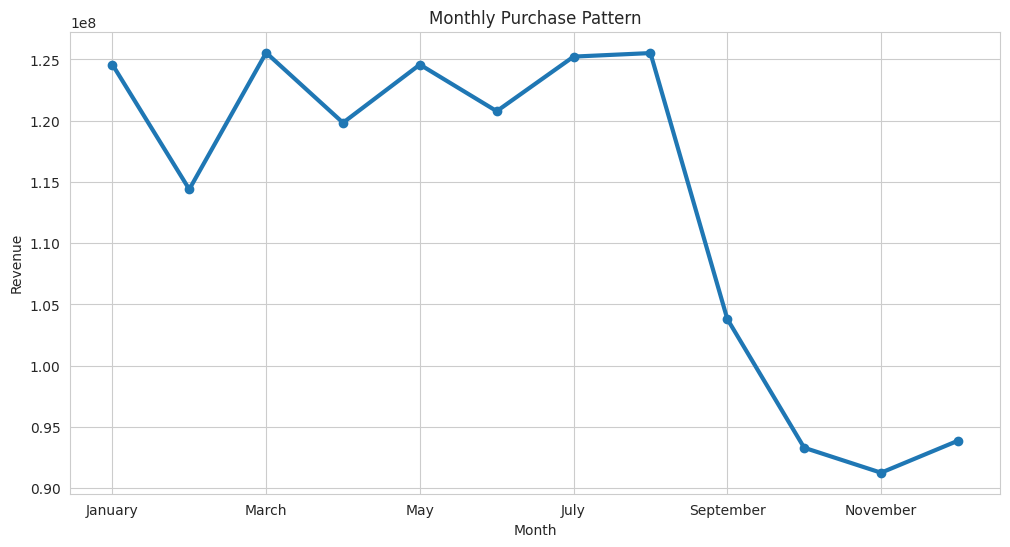


Customer Retention Analysis


,count
Retained,
Retained,25090
Not Retained,24908


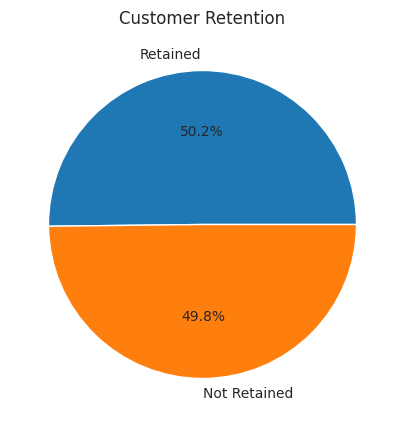

Retained,Not Retained,Retained
Customer Segment,,
At Risk,7352,485
High Value,4738,8305
Loyal,6417,7901
Regular,6401,8399


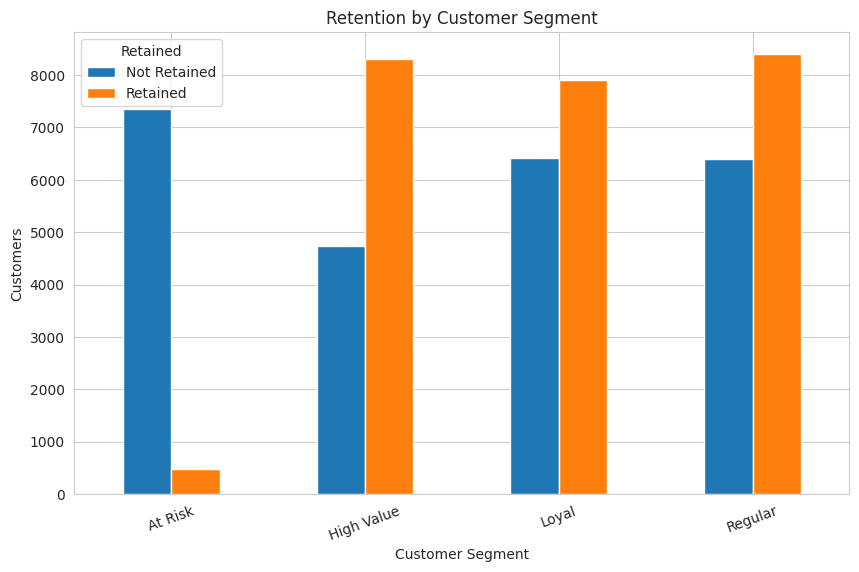


Customer Lifetime Value


,Customer ID,Monetary,Frequency,CLV
0,1,9781,4,39124
1,2,24469,9,220221
2,3,32010,12,384120
3,4,16541,9,148869
4,5,22293,13,289809



Top 10 Customers by CLV


,Customer ID,Purchase Date,Monetary,Quantity,Age,Gender,Returns,Churn,Frequency,Recency,R_Score,F_Score,M_Score,RFM Score,Cluster,Customer Segment,CLV
36434,36437,2023-08-25 12:36:58,74138,68,70,Male,9.0,0,24,21,4,4,4,444,1,High Value,1779312
42193,42196,2023-07-23 20:52:02,76910,73,59,Male,11.0,0,23,54,3,4,4,344,1,High Value,1768930
19407,19409,2023-09-06 08:45:24,71463,72,60,Female,13.0,1,24,10,4,4,4,444,1,High Value,1715112
31710,31712,2023-07-13 11:59:31,71208,73,39,Female,10.0,0,23,65,3,4,4,344,1,High Value,1637784
49740,49743,2023-07-28 03:20:38,72526,66,21,Male,10.0,0,22,50,3,4,4,344,1,High Value,1595572
36946,36949,2023-09-02 20:39:45,67541,72,37,Female,10.0,1,23,13,4,4,4,444,1,High Value,1553443
46626,46629,2023-09-14 10:25:08,64477,62,28,Female,9.0,0,24,2,4,4,4,444,1,High Value,1547448
42294,42297,2023-06-21 00:25:16,65529,62,23,Female,11.0,0,23,87,3,4,4,344,1,High Value,1507167
24938,24940,2023-09-07 17:48:24,71661,59,69,Female,9.0,1,21,8,4,4,4,444,1,High Value,1504881
26363,26365,2023-07-02 05:11:11,65060,68,19,Male,14.0,1,23,76,3,4,4,344,1,High Value,1496380


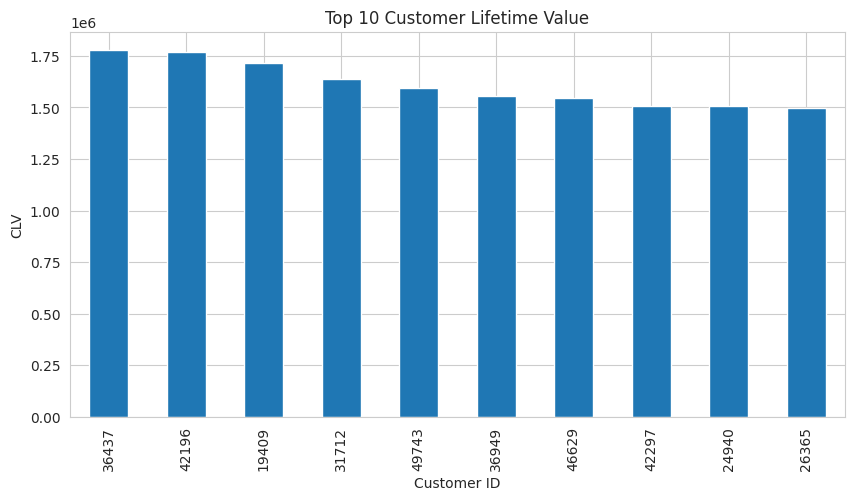


Churn Analysis


,count
Churn,
0,32074
1,17924


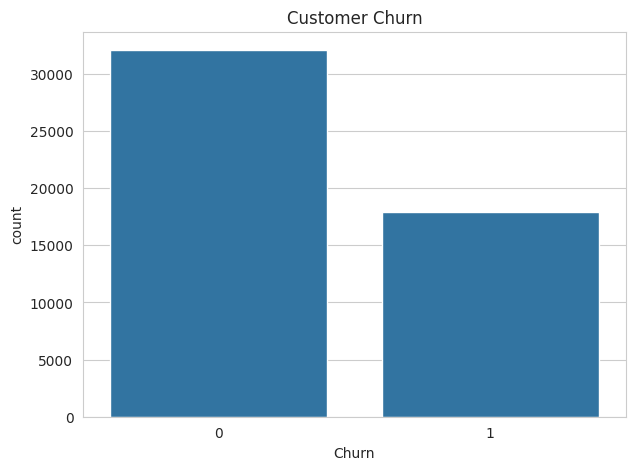

Churn,0,1
Customer Segment,,
At Risk,5069,2768
High Value,8330,4713
Loyal,9198,5120
Regular,9477,5323


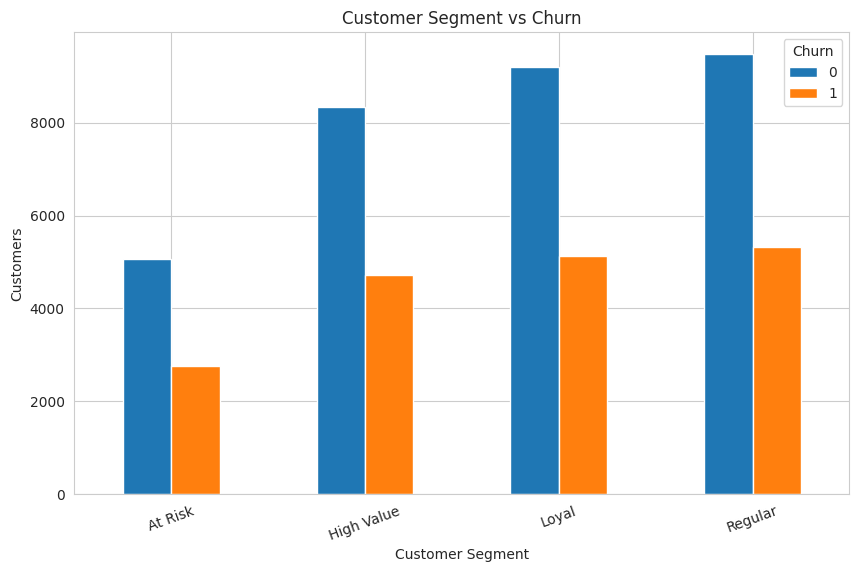

FINAL BUSINESS FINDINGS
1. Revenue is concentrated among a relatively small group of high-value customers.
2. Customer segmentation clearly distinguishes high-value, loyal, regular and at-risk customers.
3. Retention analysis indicates that customers with lower recency are more likely to remain active.
4. Customers with higher frequency and monetary value generate significantly higher lifetime value.
5. Targeted marketing based on customer segments can improve engagement and reduce churn.
FINAL RECOMMENDATIONS
1. Reward high-value customers with premium loyalty programs.
2. Launch win-back campaigns for at-risk customers using personalized discounts.
3. Increase marketing focus on high-performing product categories.
4. Use customer segmentation to personalize product recommendations.
5. Monitor customer retention and churn monthly using the RFM dashboard.

Analysis Tables Exported Successfully!
PART 4 COMPLETED SUCCESSFULLY


In [16]:
# ==========================================================
# PART 4 : PURCHASE PATTERN, RETENTION & BUSINESS REPORTING
# ALFIDO TECH INTERNSHIP PROJECT
# ==========================================================

print("="*80)
print("PART 4 : PURCHASE PATTERN & RETENTION ANALYSIS")
print("="*80)

# ==========================================================
# PURCHASE PATTERN ANALYSIS
# ==========================================================

print("\nPurchase Pattern Analysis")

monthly_purchase = (
    df.groupby("Month")["Total Purchase Amount"]
      .sum()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

display(monthly_purchase)

plt.figure(figsize=(12,6))

monthly_purchase.plot(
    marker="o",
    linewidth=3
)

plt.title("Monthly Purchase Pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

# ==========================================================
# RETENTION ANALYSIS
# ==========================================================

print("\nCustomer Retention Analysis")

retention = customer_df.copy()

retention["Retained"] = np.where(
    retention["Recency"] <= retention["Recency"].median(),
    "Retained",
    "Not Retained"
)

retention_summary = retention["Retained"].value_counts()

display(retention_summary)

plt.figure(figsize=(7,5))

retention_summary.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Customer Retention")

plt.show()

# ==========================================================
# RETENTION BY SEGMENT
# ==========================================================

segment_retention = pd.crosstab(

    retention["Customer Segment"],

    retention["Retained"]

)

display(segment_retention)

segment_retention.plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Retention by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

# ==========================================================
# CUSTOMER LIFETIME VALUE (CLV)
# ==========================================================

print("\nCustomer Lifetime Value")

customer_df["CLV"] = (

    customer_df["Monetary"]

    *

    customer_df["Frequency"]

)

display(customer_df[

    ["Customer ID","Monetary","Frequency","CLV"]

].head())

top_clv = customer_df.sort_values(

    "CLV",

    ascending=False

).head(10)

print("\nTop 10 Customers by CLV")

display(top_clv)

plt.figure(figsize=(10,5))

top_clv.set_index("Customer ID")["CLV"].plot(kind="bar")

plt.title("Top 10 Customer Lifetime Value")

plt.ylabel("CLV")

plt.show()

# ==========================================================
# CHURN ANALYSIS
# ==========================================================

print("\nChurn Analysis")

churn_summary = customer_df["Churn"].value_counts()

display(churn_summary)

plt.figure(figsize=(7,5))

sns.countplot(

    data=customer_df,

    x="Churn"

)

plt.title("Customer Churn")

plt.show()

# ==========================================================
# CHURN BY SEGMENT
# ==========================================================

segment_churn = pd.crosstab(

    customer_df["Customer Segment"],

    customer_df["Churn"]

)

display(segment_churn)

segment_churn.plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Customer Segment vs Churn")

plt.xlabel("Customer Segment")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

# ==========================================================
# FINAL BUSINESS FINDINGS
# ==========================================================

print("="*80)
print("FINAL BUSINESS FINDINGS")
print("="*80)

findings = [

"Revenue is concentrated among a relatively small group of high-value customers.",

"Customer segmentation clearly distinguishes high-value, loyal, regular and at-risk customers.",

"Retention analysis indicates that customers with lower recency are more likely to remain active.",

"Customers with higher frequency and monetary value generate significantly higher lifetime value.",

"Targeted marketing based on customer segments can improve engagement and reduce churn."

]

for i, finding in enumerate(findings, start=1):

    print(f"{i}. {finding}")

# ==========================================================
# FINAL RECOMMENDATIONS
# ==========================================================

print("="*80)
print("FINAL RECOMMENDATIONS")
print("="*80)

recommendations = [

"Reward high-value customers with premium loyalty programs.",

"Launch win-back campaigns for at-risk customers using personalized discounts.",

"Increase marketing focus on high-performing product categories.",

"Use customer segmentation to personalize product recommendations.",

"Monitor customer retention and churn monthly using the RFM dashboard."

]

for i, rec in enumerate(recommendations, start=1):

    print(f"{i}. {rec}")

# ==========================================================
# EXPORT REPORT TABLES
# ==========================================================

monthly_purchase.to_csv("Monthly_Purchase_Pattern.csv")

retention_summary.to_csv("Retention_Summary.csv")

segment_retention.to_csv("Retention_By_Segment.csv")

top_clv.to_csv("Top10_CLV_Customers.csv", index=False)

print("\nAnalysis Tables Exported Successfully!")

print("="*80)
print("PART 4 COMPLETED SUCCESSFULLY")
print("="*80)